<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE-NO-SUPERVISADO/blob/main/Parcial_2_Mario_Guerrero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parcial 2**

**Fecha de entrega:**  4 de mayo - 12:00 pm

Se tiene la base de datos ```bank_customers_satisfaction.csv``` la cual reporta la satisfacción de los consumidores con respecto a su banco y los servicios que este le presta.

La base de datos reporta las siguientes variables:

*   ```client_id```: id del cliente.
*   ```client_age```: edad del cliente.
*   ```customer_since```: desde que año es cliente del banco.
*   ```bank_account (yes/no)```: 	si tiene cuenta bancaria con el banco.
*   ```credit_card (yes/no)```: si tiene tarjeta de crédito con el banco.
*   ```mortgage (yes/no)```: si tiene hipoteca con el banco.
*   ```total_number_of_products```: número de productos financieros que tiene con el banco.
*   ```customer_income```: ingresos totales en US dollars al año del consumidor.
*   ```customer_debt```: monto actual de la deuda en US dollars que tiene el cliente con el banco.
*   ```city```: ciudad a la que pertenece la oficina del banco donde se registró el cliente en el banco.
*   ```bank```: banco con el que tiene los productos financieros el cliente.
*   ```branch```: oficina del banco donde se registró el cliente en el banco.
*   ```use_of_digital_channels (High/Moderate/Low)```: Nivel de uso de los canales digitales por parte del cliente.
*   ```use_of_branches (High/Moderate/Low)```: Nivel de uso de las oficinas del banco por parte del cliente.
*   ```bank_service_message```: opinión del cliente con respecto a su satisfacción general del servicio que le presta el banco.

## Informe solicitado

Usted trabaja de uno de los bancos reportados en la base de datos y se espera que usted haga un análisis que incluya lo siguiente:
1.   **```(50%)```** Creación de grupos homógeneos de los clientes en la base de datos, para enviarles una oferta de productos financieros acorde a sus necesidades. Reportando en cada grupo como es el sentimiento de los consumidores con respecto a su banco.
2.   **```(50%)```** Análisis y clasificación de las opiniones de los clientes con respecto a la satisfacción de los clientes en general con respecto a su banco.
  *   Nivel de satisfacción del cliente con su banco.
  *   Razón principal por la que está satisfecho o insatisfecho con su banco.
  *   Caracterización de la satisfacción de los clientes por otras variables.

## Nota
*   **Este trabajo es individual**, NO se permiten entregas iguales o similares.
*   **Uso de inteligencia artificial limitado**: el uso de inteligencia artificial es permitido, pero debe ser limitado, que se observe que el estudiante se apoya en ella, mas no que es un trabajo en su gran mayoría realizado por una inteligencia artificial.

**El informe debe claramente mostrar el análisis del estudiante y que este no es generado por IA**

---




# Rúbrica de evaluación

## Creación de grupos homógeneos (50%)

1.	Preprocesamiento de los datos (40%)
  *   Limpieza de los datos (25%)
  *   Transformación y creación de variables (15%)
2.	Exploración preliminar de los datos (10%)
  *   Gráficos de visualización
  *   Descripción de los hallazgos preliminares
3.	Desarrollo de modelos (25%)
  *   Selección de variables
  *   Preparación de variables
  *   Modelos analizados
  *   Modelo seleccionado y su justificación
  *   Presentación de los hallazgos
4.	Modelo entrenado guardado listo para asignar nuevas observaciones (10%)
5.	Informe ejecutivo de resultados (25%)

## Análisis y clasificación de la satisfacción de los clientes (50%)

1.	Procesamiento de los mensajes y creación de niveles de satisfacción (35%)
2.	Razón principal por la que está satisfecho o insatisfecho con su banco (25%)
3.	Informe ejecutivo de resultados (40%)

**0. cargamos librerias y conexion a google drive**

In [1]:
# Librerías principales
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Previsualizacion**

In [13]:
df = pd.read_csv("/content/drive/MyDrive/APREN. NO SUPERVISADO/bank_customers_satisfaction.csv")
df.head()
df.info()
df.describe()

,client_id,client_age,customer_since,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message
0,SHZV-1493-NEVC-8912,78,2016,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,I've had an excellent experience with the bank...
1,SULL-1078-YORL-8055,58,2018,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,I've had an excellent experience with the bank...
2,WLYJ-9126-OZSF-4196,76,2007,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...
3,VZMD-7697-CKUK-6198,59,2002,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,I've had an excellent experience with the bank...
4,WTBA-2990-KOZM-6501,67,2021,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...


**2. Limpieza de datos**

In [ ]:
# Ver valores nulos
df.isnull().sum()

In [9]:
df.dtypes

,0
client_id,object
client_age,int64
customer_since,int64
bank_account,object
credit_card,object
mortgage,object
total_number_of_products,int64
customer_income,float64
customer_debt,float64
city,object


**3. EXPLORACIÓN PRELIMINAR**

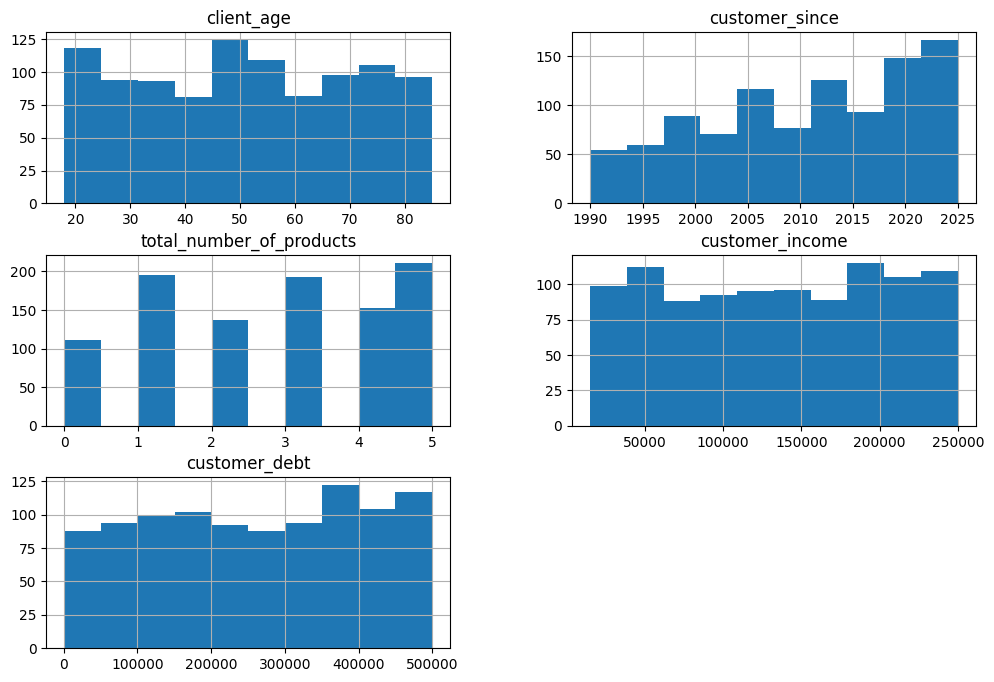

In [10]:
# Distribución de variables numéricas
df.hist(figsize=(12,8))
plt.show()

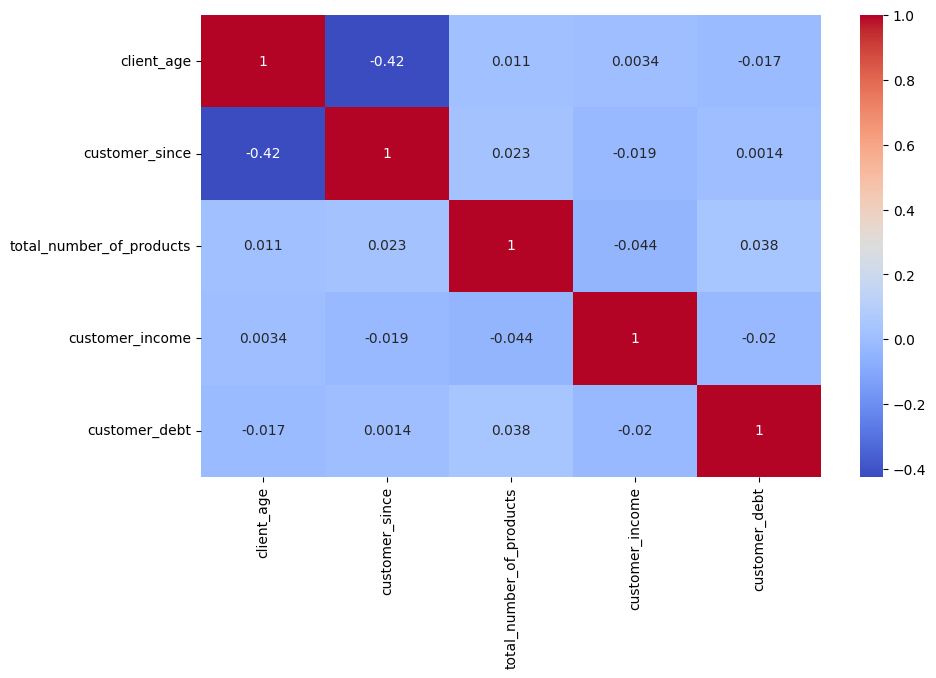

In [11]:
# Matriz de correlación
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [12]:
# Variables categóricas
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


client_id
client_id
VXDB-5594-FOLT-1835    1
SHZV-1493-NEVC-8912    1
SULL-1078-YORL-8055    1
WLYJ-9126-OZSF-4196    1
VZMD-7697-CKUK-6198    1
                      ..
NLTP-7843-YXIO-8608    1
UMOF-6529-NODK-6157    1
EZHK-7506-YFVX-3858    1
XIBY-4200-ESKY-1874    1
AFRG-8283-RKOR-5221    1
Name: count, Length: 1000, dtype: int64

bank_account
bank_account
yes    520
no     480
Name: count, dtype: int64

credit_card
credit_card
yes    508
no     492
Name: count, dtype: int64

mortgage
mortgage
yes    510
no     490
Name: count, dtype: int64

city
city
Seattle          108
Dallas           105
Boston           105
Austin           102
Chicago          101
Denver            99
Miami             97
San Francisco     96
Los Angeles       94
New York          93
Name: count, dtype: int64

Bank
Bank
Chase               394
Wells Fargo         304
Bank of America     302
Name: count, dtype: int64

Branch
Branch
Seattle Pike Street    108
Main Street Dallas     105
Boylston Street        1

**4. TRANSFORMACIÓN Y CREACIÓN DE VARIABLES**

In [14]:
# Variables numéricas y categóricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [15]:
# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

In [23]:
X = preprocessor.fit_transform(df)

**5. CREACIÓN DE GRUPOS HOMOGÉNEOS**

In [18]:
from sklearn.cluster import KMeans

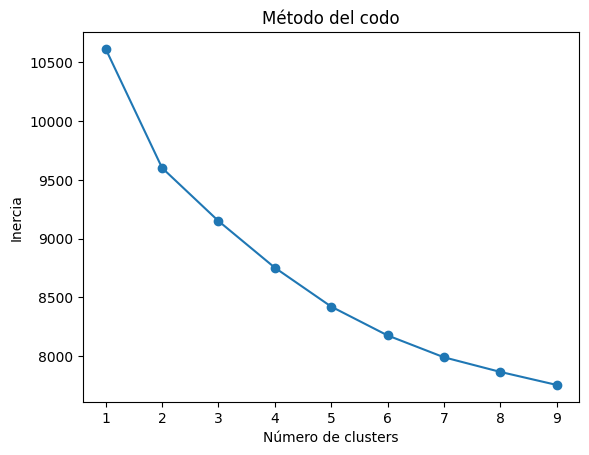

In [19]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

In [21]:
df.groupby('cluster').mean(numeric_only=True)

,client_age,customer_since,total_number_of_products,customer_income,customer_debt
cluster,,,,,
0,44.193333,2015.476667,0.963333,135189.859100,260889.807533
1,65.063492,2000.875661,2.917989,139118.685635,260599.579656
2,41.024845,2016.838509,4.108696,127697.219099,261817.060621


In [24]:
df['cluster'].value_counts()

,count
cluster,
1,378
2,322
0,300


**6. MODELO GUARDADO**

In [22]:
import joblib

joblib.dump(kmeans, "modelo_kmeans.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

# **7. Informe ejecutivo de modelo Kmeans**

Antes de empezar con el informe me parece necesario hacer un analisis de los resultados para de esta manera poder tomar decisiones estraegicas para la empresa.

**Cluster 0:**


*   300 Clientes
*   44 Años (edad media)
*  Pocos Productos (0.96)
* Ingresos altos
* Deuda media-alta

**Cluster 1:**

*   378 Clientes
*   65 Años (Edad más alta)
*  Casi 3 productos por cliente
* Ingresos altos
* Deuda más baja relativa

**Cluster 2:**

* 322 Clientes
* Más jóvenes (41 años)
* Mayor número de productos (4)
* Ingresos más bajos del grupo
* Mayor nivel de deuda

Ahora si, despues de desglozar estos resultados se puede hacer un analisis clave para la empresa donde pueda darse cuenta de sus dolores y sus fortalezas.


# **INFORME**

Para empezar, el cluster 0 es un grupo con alto ingreso pero baja vinculacion en el banco, aqui esta un grupo con alta probabilidad de crecimiento. Tambien podemos ver que el cluster 1 representa los clientes mas antiguos y fieles al banco, estos son los mas valiosos y estables de la emresa. y por ultimo, el cluster 2 que me parece un cluster con bastate interaccion con el banco por que es el que mas productos tiene pero es el de ingresos mas bajo y mayor nivel de deuda, esto puede impactar la rentabilidad del banco.

A continuacion, dejare algunas recomendaciones para cada uno de los clusters.  para el cluster 0, se pueden usar estrategias de cross selling, como con creditos o inversiones. Ya que, estos clientes tienen mucho potencial y se esta desarpovechando. Para el cluster 1, ya que son los clientes mas antiguos y con mayor valor, sse pueden realizar programas de fidelizacion o programas premium para que estos clientes se sientan mas atraidos y recomienden absatnte la marca. Ademas, sabemos que son los clientes de mayor edad, estos lo mejor es darles una atencion personalizada debido a su edad y su gran valor en la empresa. Por ultimo, para el cluster 2 lo mejor seria tener un buen manejo del riesgo o un buen control. A estos clientes se les puede ofrecer productos del banco con mucho mas control para que de esta manera no puedan excederse en su deuda. Ademas, se pueden hacer cursos gratis para estas personas sobre educaccion financiera y de esta manera reducir el endaudamiento grande el grupo.

El modelo permite segmentar a los clientes de forma clara y accionable, facilitando estrategias diferenciadas por perfil. Además, puede ser utilizado para clasificar nuevos clientes y mejorar la toma de decisiones comerciales del banco.

# **ANÁLISIS DE SENTIMIENTOS**

**8. PROCESAMIENTO DE LOS MENSAJES**

In [25]:
# Librerías NLP
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [26]:
def limpiar_texto(texto):
    texto = texto.lower()  # minúsculas
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)  # eliminar números y signos
    texto = texto.split()

    # eliminar stopwords
    palabras = [word for word in texto if word not in stopwords.words('english')]

    return " ".join(palabras)

# aplicar limpieza
df['clean_message'] = df['bank_service_message'].astype(str).apply(limpiar_texto)

df[['bank_service_message', 'clean_message']].head()

,bank_service_message,clean_message
0,I've had an excellent experience with the bank...,ive excellent experience banks helpful financi...
1,I've had an excellent experience with the bank...,ive excellent experience banks fraud protectio...
2,My recent interactions with the bank have been...,recent interactions bank disappointing particu...
3,I've had an excellent experience with the bank...,ive excellent experience banks seamless online...
4,My experience with the bank has been generally...,experience bank generally fine especially rega...


**9. ANÁLISIS DE SENTIMIENTO**

In [27]:
from textblob import TextBlob

In [28]:
def obtener_sentimiento(texto):
    analisis = TextBlob(texto)
    return analisis.sentiment.polarity

df['sentimiento'] = df['clean_message'].apply(obtener_sentimiento)

**10. CLASIFICACIÓN DE SATISFACCIÓN**

In [29]:
def clasificar_sentimiento(valor):
    if valor > 0:
        return "Satisfecho"
    elif valor == 0:
        return "Neutral"
    else:
        return "Insatisfecho"

df['nivel_satisfaccion'] = df['sentimiento'].apply(clasificar_sentimiento)

In [30]:
df['nivel_satisfaccion'].value_counts()

,count
nivel_satisfaccion,
Satisfecho,788
Insatisfecho,212


**11. RAZONES PRINCIPALES**

In [31]:
for nivel in df['nivel_satisfaccion'].unique():
    print(f"\n{nivel}")

    textos = df[df['nivel_satisfaccion'] == nivel]['clean_message']
    palabras = " ".join(textos).split()

    freq = pd.Series(palabras).value_counts().head(10)
    print(freq)


Satisfecho
service       863
banking       847
experience    807
much          788
team          599
using         599
excellent     599
ive           599
services      599
made          599
Name: count, dtype: int64

Insatisfecho
slow             235
banking          232
customer         230
recent           212
disappointing    212
bank             212
particularly     212
related          212
support          212
multiple         212
Name: count, dtype: int64


# **12. INFORME EJECUTIVO ANALISIS DE SENTIMIENTOS**

Antes de empezar con el informe me parece importante (Como hice en el otro analisis). De esta manera, podemos tomar las mejores decisiones estrategicas para la empresa.

**Satisfechos:**
* 788 Clientes
* Los comentarios están dominados por palabras como “service”, “experience”, “team”, “excellent” y “easy”
* lo que indica que los clientes valoran principalmente:

1. La calidad del servicio
2. La experiencia general con el banco
3. La atención del equipo

**Insatisfecho:**

* 212 Clientes
* En este grupo destacan palabras como “slow”, “customer”, “disappointing”, “support” y “multiple”
* lo que refleja problemas asociados a:

1. Lentitud en los procesos
2. Fallas en la atención al cliente
3. Experiencias frustrantes o inconsistentes

Despues de ya tener los resultados analizados ahora si seguimos con el informe.

# **INFORME EJECUTIVO**

Para empezar es importante decir que, la satisfaccion del cliente esta ligada basicamente a la atencion al cliente y la experiencia que la marca ofrece. por otro lado, la insatisfaccion de clientes del banco se debe plenamente a problemas operativos, como el alto tiempo de espera en las preguntas de los clientes. es decir el error fuerte estae n los altos tiempos de espera y soporte. Segun lo que se puede revisar en el analisis de sentimientos no existe una critica fuerte al banco si no mas que todo a momentos especificos entre la interaccion cliente-empleado.

A continuacion mencionare algunas recomendaciones estrategicas que siento que le pueden servir al banco. para empezar, optimizar los tiempos de respuesta. Esto reduce los tiempos altos de espera y ademas reduce la friccion entre los clientes y las personas que atienden. Otro punto importante para tocar es, fortalecer el area de soporte. Esto se puede hacer recibiendo capacitaciones de otras marcas que sea reconocidas por su gran atencion al cliente ( se sabe que dentro del gremio de los bancos esto es muy dificil), Ademas hacer un entrenamiento con todo el equipo para aumentar sus capacidades de soporte. otro punto seria, estandarizar la experiencia del ususario. De esta manera se evitan las inconsistencias. asi cada cliente recibe una atencion estandar y de esat manera todo se puede medir or KPI y cada tiempo de atencion tiene un estandar. Por ultimo, se debe potenciar lo que ya funciona. Por ejemplo, esos testimoios de cosas que ya funcionann para la empresa se pueden usar para marketing o para mismos programas de fidelizacion.

Para concluir, A pesar de que mi opinion personal sea que el analisis de sentimientos hoy en dia realizarlo en python queda muy obsoleto por que siento que no segmenta bien, con base a lo que se tiene se pueden tomar muy buenas decisiones. El banco cuenta con una base sólida de clientes satisfechos, pero enfrenta oportunidades claras de mejora en la operación del servicio. Atacar estos puntos críticos puede generar un impacto directo en la percepción del cliente y su fidelización.